# 多值干预归因：GACRNet on EconML Multi-Attribution

本 notebook 演示 `GACRNet` 在 EconML 多归因数据上的用法。这是一个**三类干预**场景：
- `t=0`：无干预（控制组）
- `t=1`：仅 Tech Support
- `t=2`：仅 Discount

（同时开两个干预的样本作为组合干预，见 notebook 03。）

**数据**：`load_multi_attribution` 不带参数时自动从 EconML 官方 URL 下载到 `~/.causalmt_cache/`。
如果你已有本地副本（如用户的 `multi_attribution_synthetic.csv` 含真值列），传路径即可。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from causalmt import GACRNet
from causalmt.data import load_multi_attribution
from causalmt.metrics import ate_error, pehe

# 中文标签字体（按平台依次回退）
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti TC", "STHeiti", "Microsoft YaHei", "SimHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 用本地扩展版（含 tau 真值），也可以传 None 让其自动下载 EconML 原始版
DATA_PATH = Path("~/Graduate/Work/毕业论文/数据集/multi_attribution_synthetic.csv").expanduser()
# DATA_PATH = None  # 用此行则自动下载官方原始版（无真值，无法计算 PEHE）

## 1. 加载原子干预样本

In [2]:
ds = load_multi_attribution(DATA_PATH, split="atomic")
print(ds)
print(f"特征: {ds.feature_names}")
print(f"干预分布: {dict(zip(*np.unique(ds.t, return_counts=True)))}")
if ds.ate_true is not None:
    print(f"真实 ATE (T1 vs ctrl): {ds.ate_true:.3f}")

CausalDataset(name='multi_attribution_atomic', n=1456, d=8, K=3, has_potential=True, has_cate_true=True)
特征: ('Global Flag', 'Major Flag', 'SMC Flag', 'Commercial Flag', 'logIT', 'logEmp', 'logPC', 'logSize')
干预分布: {0: 517, 1: 462, 2: 477}
真实 ATE (T1 vs ctrl): 8.593


## 2. 训练/测试切分 + 标准化

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 后 4 列是连续特征，需要标准化
n_binary = 4
X_tr, X_te, t_tr, t_te, y_tr, y_te, cate_tr, cate_te = train_test_split(
    ds.x, ds.t, ds.y, ds.cate_true if ds.cate_true is not None else np.zeros(ds.n),
    test_size=0.2, random_state=42, stratify=ds.t,
)

x_scaler = StandardScaler()
X_tr_cont = x_scaler.fit_transform(X_tr[:, n_binary:])
X_te_cont = x_scaler.transform(X_te[:, n_binary:])
X_tr = np.hstack([X_tr[:, :n_binary], X_tr_cont]).astype(np.float32)
X_te = np.hstack([X_te[:, :n_binary], X_te_cont]).astype(np.float32)

y_scaler = StandardScaler()
y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1, 1)).flatten().astype(np.float32)
y_te_s = y_scaler.transform(y_te.reshape(-1, 1)).flatten().astype(np.float32)

print(f"训练: {X_tr.shape}, 测试: {X_te.shape}")

训练: (1164, 8), 测试: (292, 8)


## 3. 训练多干预 GACRNet (K=3)

In [4]:
est = GACRNet(
    num_treatments=3,          # 0=ctrl, 1=Tech Support, 2=Discount
    backbone="mlp",
    head="uplift",
    routing="gps",             # 论文默认
    hidden_dim=200,
    head_hidden=100,
    use_mmd=True,
    mmd_weight=1.0,
    use_tarreg=True,
    epochs=300,
    batch_size=128,
    lr=1e-3,
    early_stopping_patience=30,
    verbose=False,
    random_state=42,
)
est.fit(X_tr, t_tr, y_tr_s)
print(f"最佳验证集损失 {est.history_['best_val_loss']:.4f} @ epoch {est.history_['best_epoch']}")

最佳验证集损失 1.2188 @ epoch 116


## 4. 估计每个干预的 ATE 和 CATE

In [5]:
# 反标准化方便对比真值（真值是原始尺度的 Revenue 增量）
y_std = float(y_scaler.scale_[0])

ate_t1 = est.estimate_ate(X_te, treatment_a=1, treatment_b=0) * y_std
ate_t2 = est.estimate_ate(X_te, treatment_a=2, treatment_b=0) * y_std

cate_t1 = est.estimate_cate(X_te, treatment_a=1, treatment_b=0) * y_std
cate_t2 = est.estimate_cate(X_te, treatment_a=2, treatment_b=0) * y_std

print(f"ATE(Tech Support vs ctrl): {ate_t1:.3f}")
print(f"ATE(Discount    vs ctrl): {ate_t2:.3f}")

if ds.cate_true is not None:
    tau1_true = cate_te.astype(np.float32)
    print()
    print(f"PEHE (T1 vs ctrl):    {pehe(cate_t1, tau1_true):.3f}")
    print(f"ATE_err (T1 vs ctrl): {ate_error(cate_t1, tau1_true):.3f}")

ATE(Tech Support vs ctrl): 8.074
ATE(Discount    vs ctrl): 3.749

PEHE (T1 vs ctrl):    0.650
ATE_err (T1 vs ctrl): 0.507


## 5. 异质效应分析

查看不同客户类型（Major Flag）下两个干预的效应分布。

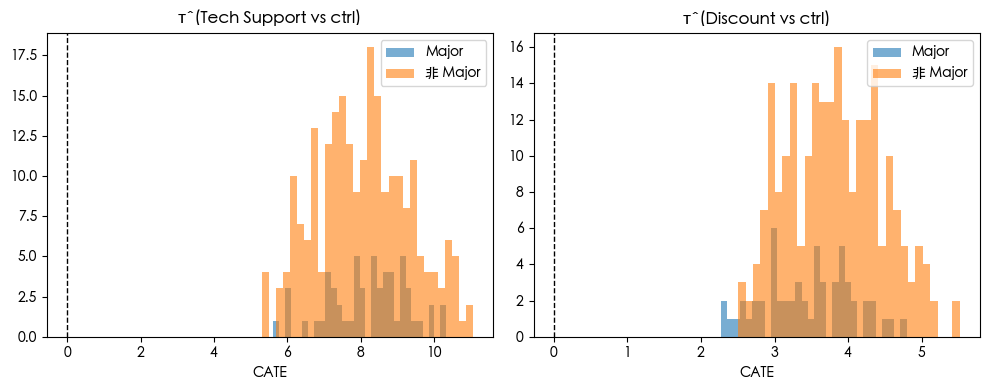

In [6]:
major_idx = list(ds.feature_names).index("Major Flag")
is_major = X_te[:, major_idx] == 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cate, label) in zip(axes, [(cate_t1, "Tech Support"), (cate_t2, "Discount")]):
    ax.hist(cate[is_major], bins=30, alpha=0.6, label="Major", color="C0")
    ax.hist(cate[~is_major], bins=30, alpha=0.6, label="非 Major", color="C1")
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("CATE")
    ax.set_title(f"τ̂({label} vs ctrl)")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. 个性化最优干预选择

对每个客户，选择带来最大 Revenue 增量的干预（含"不干预"选项）。

In [7]:
po = est.predict_potential_outcomes(X_te) * y_std  # (n, 3)
best_t = po.argmax(axis=1)

print("测试集推荐分布:")
for k, label in enumerate(["无干预", "Tech Support", "Discount"]):
    cnt = (best_t == k).sum()
    print(f"  {label}: {cnt} ({cnt/len(best_t):.1%})")

测试集推荐分布:
  无干预: 0 (0.0%)
  Tech Support: 292 (100.0%)
  Discount: 0 (0.0%)
